In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import plot_settings

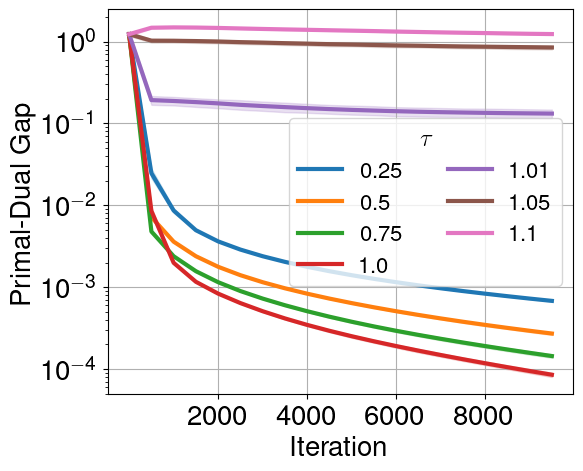

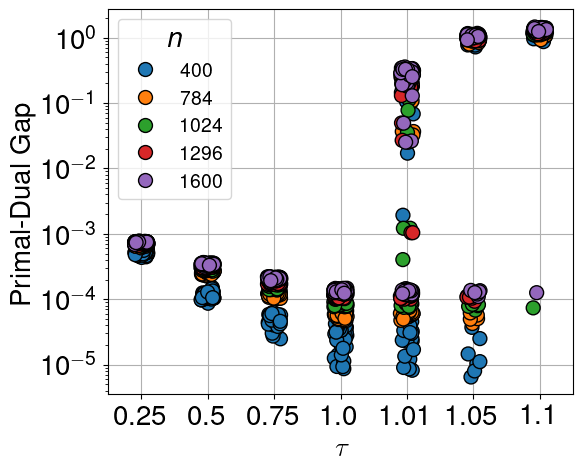

In [2]:
from matplotlib.ticker import FixedLocator
df = pd.read_csv("../data_archive/fig_1_stepsize_experiment_32.csv")
# df = df.query("N <= 1024")
df['pd_gap'] = df['primal'] - df['dual']
limdf = df.loc[(df['tau'] != 0.1) & (df['N'] > 100)]
# for n, sdf in df.groupby('N'):
fig, ax = plt.subplots(figsize=(6,5), dpi=100)
sns.lineplot(limdf,ax=ax, x='iter', y='pd_gap', hue='tau', palette = 'tab10', linewidth=3, err_style='band')
ax.set_yscale('log')
ax.legend(title='$\\tau$', title_fontsize=18, fontsize=16, ncols=2)
ax.set_ylabel("Primal-Dual Gap")
ax.set_xlabel("Iteration")
ax.xaxis.set_major_locator(FixedLocator([1000 * i for i in [2, 4, 6, 8]]))
ax.grid()
plt.show()
fig.savefig("../figures/tau_jump_lineplot.pdf", bbox_inches='tight')


fig, ax = plt.subplots(figsize=(6,5), dpi=100)
sns.stripplot(limdf.query("iter == 9501"), ax=ax, x="tau", y='pd_gap', hue='N', palette='tab10', s=10, edgecolor='k', linewidth=1)
ax.set_yscale('log')
ax.set_ylabel("Primal-Dual Gap")
ax.set_xlabel("$\\tau$")
ax.legend(title="$n$", bbox_to_anchor=(0,1), loc='upper left', fontsize=14)
ax.grid()
fig.savefig("../figures/tau_jump_stripplot.pdf", bbox_inches='tight')


/tmp/ipykernel_2302384/3676523400.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lim_df['solver'] = lim_df['solver'].replace({


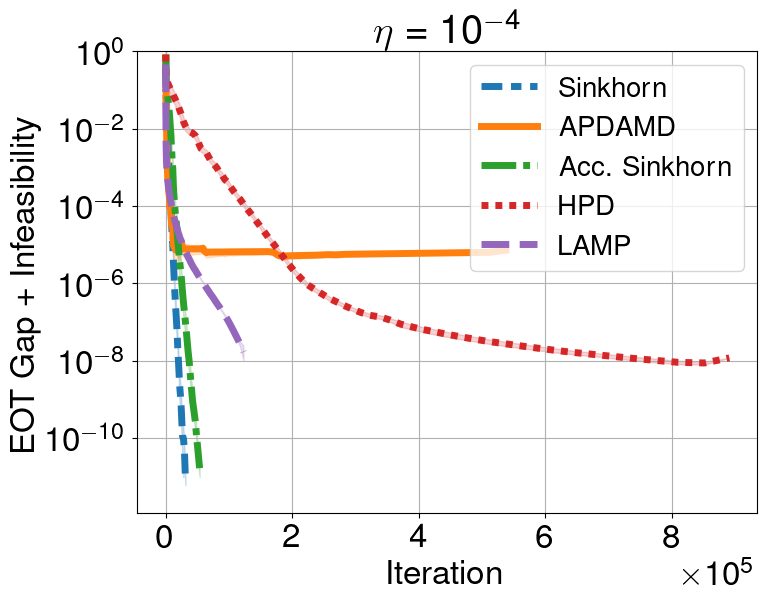

/tmp/ipykernel_2302384/3676523400.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lim_df['solver'] = lim_df['solver'].replace({


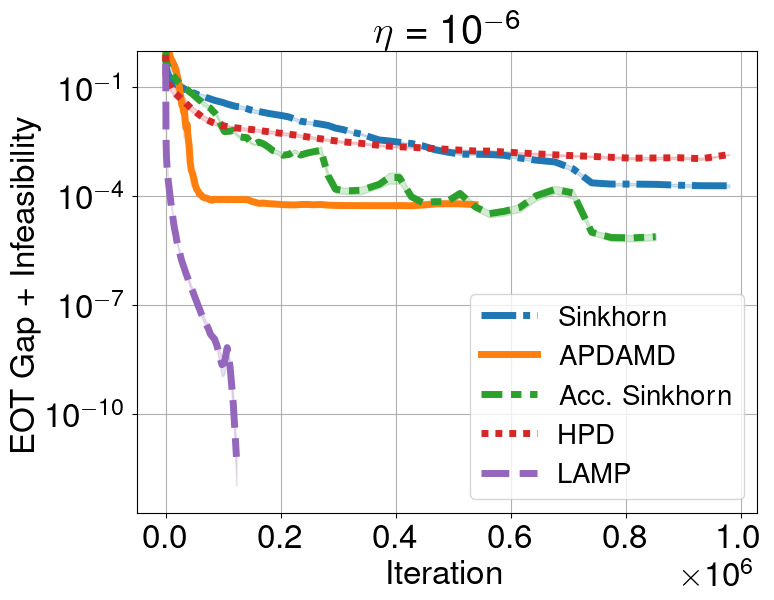

In [18]:
# probclass = 'classicimages'
import matplotlib as mpl

mpl.rcParams["font.size"] = 24
df = pd.read_csv("../data_archive/fig_2_dotmark_comp.csv")
arr = np.exp(pd.cut(np.log(df['iter']), bins=300 , precision=1,retbins=True)[0].apply(lambda x: x.mid).to_numpy())
# np.exp(arr[0].iloc[0].mid)
df['biniter'] = arr
for eta in [ 1e-4, 1e-6]:
    
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    lim_df = df.query(f'eta == {eta}')
    lim_df['solver'] = lim_df['solver'].replace({
        'apdamd': "APDAMD",
        'sinkhorn': "Sinkhorn",
        'lamp': "LAMP",
        'hpd': "HPD",
        'accelerated_sinkhorn': "Acc. Sinkhorn"
    })

    hue_order = [
        "Sinkhorn",
        "APDAMD",
        "Acc. Sinkhorn",
        "HPD",
        "LAMP"
    ]
    ax=sns.lineplot(lim_df, ax=ax, x='biniter', y='objective_gap', hue='solver', style="solver", hue_order=hue_order, linewidth=5)
    ax.set_yscale('log')
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)

    # ax.set_xscale(10000)
    ax.set_ylim((ax.get_ylim()[0], 1))
    # ax.set_xlim((ax.get_xlim()[0], 10000))
    ax.legend(fontsize=20)
    ax.grid()
    ax.set_ylabel('EOT Gap + Infeasibility')
    ax.set_xlabel('Iteration')
    ax.set_title('$\\eta=10^{%d}$' % (round(np.log10(eta))))
    plt.show()

    fig.savefig(f'../figures/broad_dotmark_1en{eta}_lamp.pdf', bbox_inches='tight')


102491


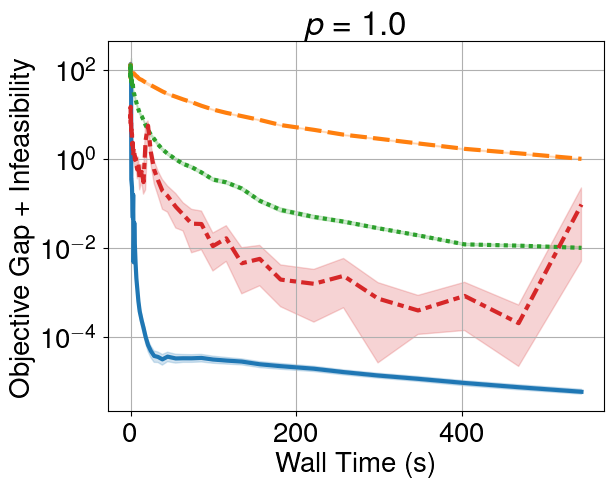

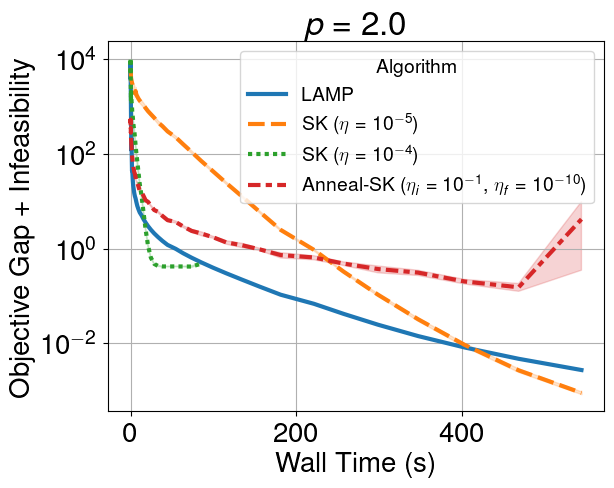

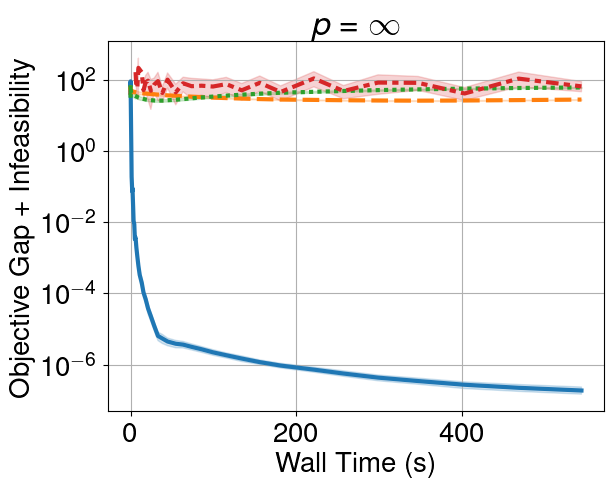

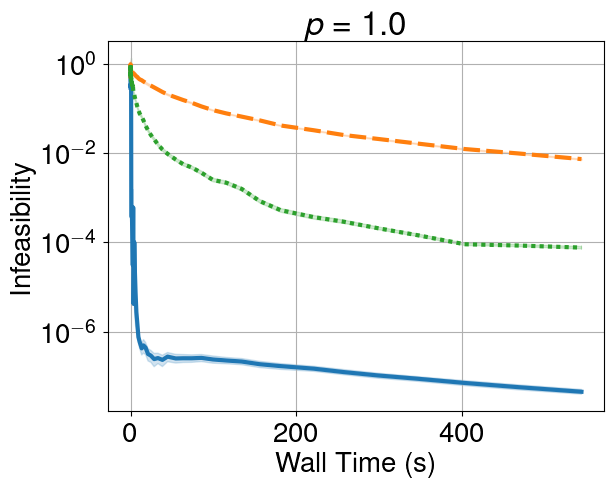

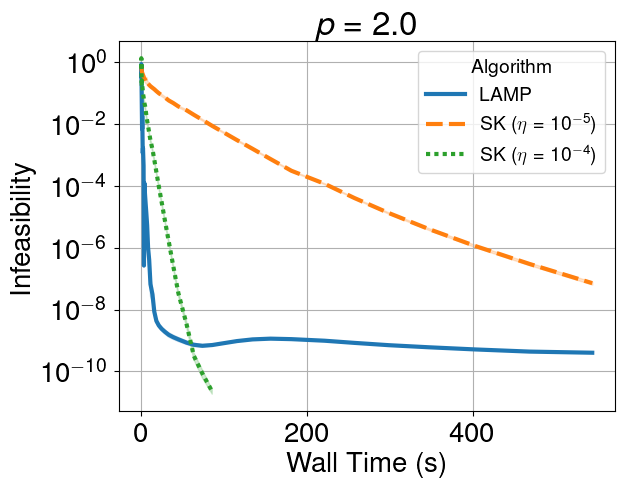

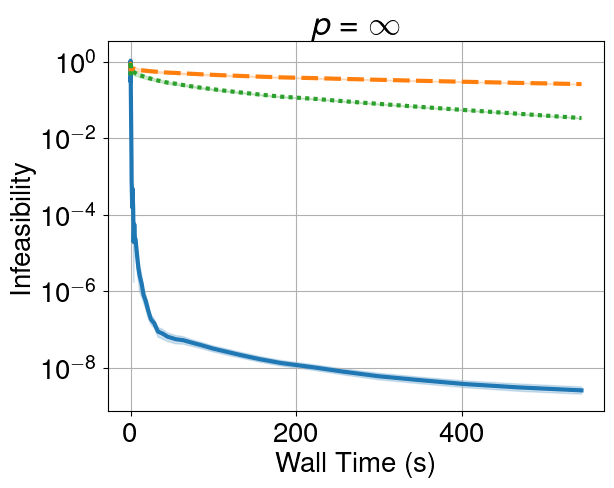

In [3]:

df=pd.read_csv("../data_archive/fig_4_updated_pnorm.csv").drop(columns=["ot_distance"])
optimal_df = pd.read_csv("../data_archive/ground_truths_pnorms_new.csv") # exact minima found via emd2
df = df.merge(optimal_df, on=['problemclass', 'problem_1', 'problem_2', 'p'])

# minvals = df.query('infeas < 1e-3').groupby(['problemclass', 'p', 'problem_1', 'problem_2'])['ot_objective'].transform("min")
# df['objgap'] = df['ot_objective'] - df['']
df["maxval"] = df["p"].replace(
    {2: 2 * 63**2,
     1: 2 * 63,
     np.inf: 63}
)
# dff["Algorithm"] = df['solver'].replace({"sinkhorn_kernel":"SK", "lamp_cuda_ctransfer": "LAMP"})
df['gap'] = abs(df['ot_objective'] - df['ot_distance']) + abs(df['infeas']) * df["maxval"]
# df["Algorithm"] = df['solver'].replace({"sinkhorn_kernel":"SK", "extragrad_dual_ctransfer": "LAMP"})
# df["time(s)"] = (df["time(s)"]/2).round()*2
print(len(df.query("Algorithm == \"SK ($\\eta = 10^{-5}$)\"")))
arr = np.exp(pd.cut(np.log(df['time(s)']), bins=100 , precision=1,retbins=True)[0].apply(lambda x: x.mid).to_numpy())
# np.exp(arr[0].iloc[0].mid)
df['bintime'] = arr
# df.to_csv("updated_pnorm.csv", index=False)
for p, sdf in df.groupby("p"):
    fig, ax = plt.subplots(dpi=100)
    # if p == np.inf:
        # sdf = sdf.query("Algorithm != \"LAMP\"")
    hue_order=["LAMP", "SK ($\\eta = 10^{-5}$)","SK ($\\eta = 10^{-4}$)" , "Anneal-SK ($\\eta_i = 10^{-1}$, $\\eta_f = 10^{-10}$)",]
    first = True
    # for (p1, p2, pclass), ssdf in sdf.groupby(["problem_1", "problem_2", "problemclass"]):
    ax=sns.lineplot(sdf, x='bintime', y='gap', hue='Algorithm', style='Algorithm',  palette='tab10',
                    legend=False if p != 2 or not first else True, 
                   hue_order=hue_order,  style_order=hue_order, linewidth=3)
    first = False
    ax.set_yscale('log')
    ax.grid()
    ssdf = np.sort(sdf['bintime'].unique())
    infeas_offset = sdf.query("Algorithm == \"LAMP\"")
        # xv = np.linspace(0, 600, 50)
    # yv = 
    
    if p==2:
        ax.legend(fontsize=14, title='Algorithm', title_fontsize=14)
    if p != np.inf:
        ax.set_title("$p=%s$" % (str(p)))
    else:
        ax.set_title("$p=\\infty$")
    ax.set_ylabel("Objective Gap + Infeasibility")
    ax.set_xlabel("Wall Time (s)")
    plt.show()
    fig.savefig("../figures/pnorm_test_4096_%s.pdf" % (str(p)), bbox_inches='tight')

# first = True
for p, sdf in df.groupby("p"):
    fig, ax = plt.subplots(dpi=100)
    # if p == np.inf:
        # sdf = sdf.query("Algorithm != \"LAMP\"")
    
    hue_order=["LAMP", "SK ($\\eta = 10^{-5}$)","SK ($\\eta = 10^{-4}$)" ]
    first = True
    ax=sns.lineplot(sdf, x='bintime', y='infeas', hue='Algorithm',style='Algorithm',  style_order=hue_order,  palette='tab10',
                    legend=False if p != 2 or not first else True, 
                    hue_order=["LAMP", "SK ($\\eta = 10^{-5}$)","SK ($\\eta = 10^{-4}$)" ], linewidth=3)

    
    sns.lineplot
    first = False
    ax.set_yscale('log')
    ax.grid()
    
    if p==2:
        ax.legend(fontsize=14, title='Algorithm', title_fontsize=14)
    if p != np.inf:
        ax.set_title("$p=%s$" % (str(p)))
    else:
        ax.set_title("$p=\\infty$")
    ax.set_ylabel("Infeasibility")
    ax.set_xlabel("Wall Time (s)")
    fig.savefig("../figures/pnorm_test_4096_%s_infeas.pdf" % (str(p)), bbox_inches='tight')
    plt.show()

In [ ]:
ax.xaxis.get_v()

'bottom'

In [12]:
df

,iter,infeas,ot_objective,dual,solver,time(s),problemclass,p,maxval,Algorithm,...,eta,primal,resolution_x,ot_distance_x,unnorm_ot_distance,gap,bintime,resolution_y,ot_distance_y,maxv
0,40,2.859474e-12,19.419670,NaN,annealed_sinkhorn_kernel,18.19480,ClassicImages,1.0,126.0,"Anneal-SK ($\eta_i = 10^{-1}$, $\eta_f = 10^{-...",...,0.100000,NaN,64,2.434253,19941.398173,16.985417,18.174145,64,2.434253,126.0
1,90,1.605451e-11,16.405512,NaN,annealed_sinkhorn_kernel,20.40557,ClassicImages,1.0,126.0,"Anneal-SK ($\eta_i = 10^{-1}$, $\eta_f = 10^{-...",...,0.079000,NaN,64,2.434253,19941.398173,13.971259,21.115344,64,2.434253,126.0
2,170,3.150484e-12,13.689316,NaN,annealed_sinkhorn_kernel,20.60082,ClassicImages,1.0,126.0,"Anneal-SK ($\eta_i = 10^{-1}$, $\eta_f = 10^{-...",...,0.062410,NaN,64,2.434253,19941.398173,11.255063,21.115344,64,2.434253,126.0
3,290,4.091895e-12,11.340611,NaN,annealed_sinkhorn_kernel,20.89361,ClassicImages,1.0,126.0,"Anneal-SK ($\eta_i = 10^{-1}$, $\eta_f = 10^{-...",...,0.049304,NaN,64,2.434253,19941.398173,8.906358,21.115344,64,2.434253,126.0
4,470,5.351585e-12,9.372331,NaN,annealed_sinkhorn_kernel,21.33411,ClassicImages,1.0,126.0,"Anneal-SK ($\eta_i = 10^{-1}$, $\eta_f = 10^{-...",...,0.038950,NaN,64,2.434253,19941.398173,6.938078,21.115344,64,2.434253,126.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15652,237801,1.620621e-02,2.112934,1834.285465,sinkhorn_kernel,597.69040,ClassicImages,1.0,126.0,SK ($\eta = 10^{-5}$),...,NaN,NaN,64,2.467624,20214.772791,2.396673,544.571910,64,2.467624,126.0
15653,238001,1.620621e-02,2.112965,1834.395894,sinkhorn_kernel,598.17920,ClassicImages,1.0,126.0,SK ($\eta = 10^{-5}$),...,NaN,NaN,64,2.467624,20214.772791,2.396641,544.571910,64,2.467624,126.0
15654,238201,1.620621e-02,2.112984,1834.506323,sinkhorn_kernel,598.66870,ClassicImages,1.0,126.0,SK ($\eta = 10^{-5}$),...,NaN,NaN,64,2.467624,20214.772791,2.396622,544.571910,64,2.467624,126.0
15655,238401,1.620621e-02,2.112997,1834.616751,sinkhorn_kernel,599.15710,ClassicImages,1.0,126.0,SK ($\eta = 10^{-5}$),...,NaN,NaN,64,2.467624,20214.772791,2.396610,544.571910,64,2.467624,126.0


In [6]:
df['Algorithm'].unique()

array(['Dual Extrap.', 'LAMP ($\\eta_p = 0$)'], dtype=object)

/tmp/ipykernel_2302384/14036799.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Algorithm"].replace({"LAMP ($\\eta_p = 0$)": "LAMP"}, inplace=True)


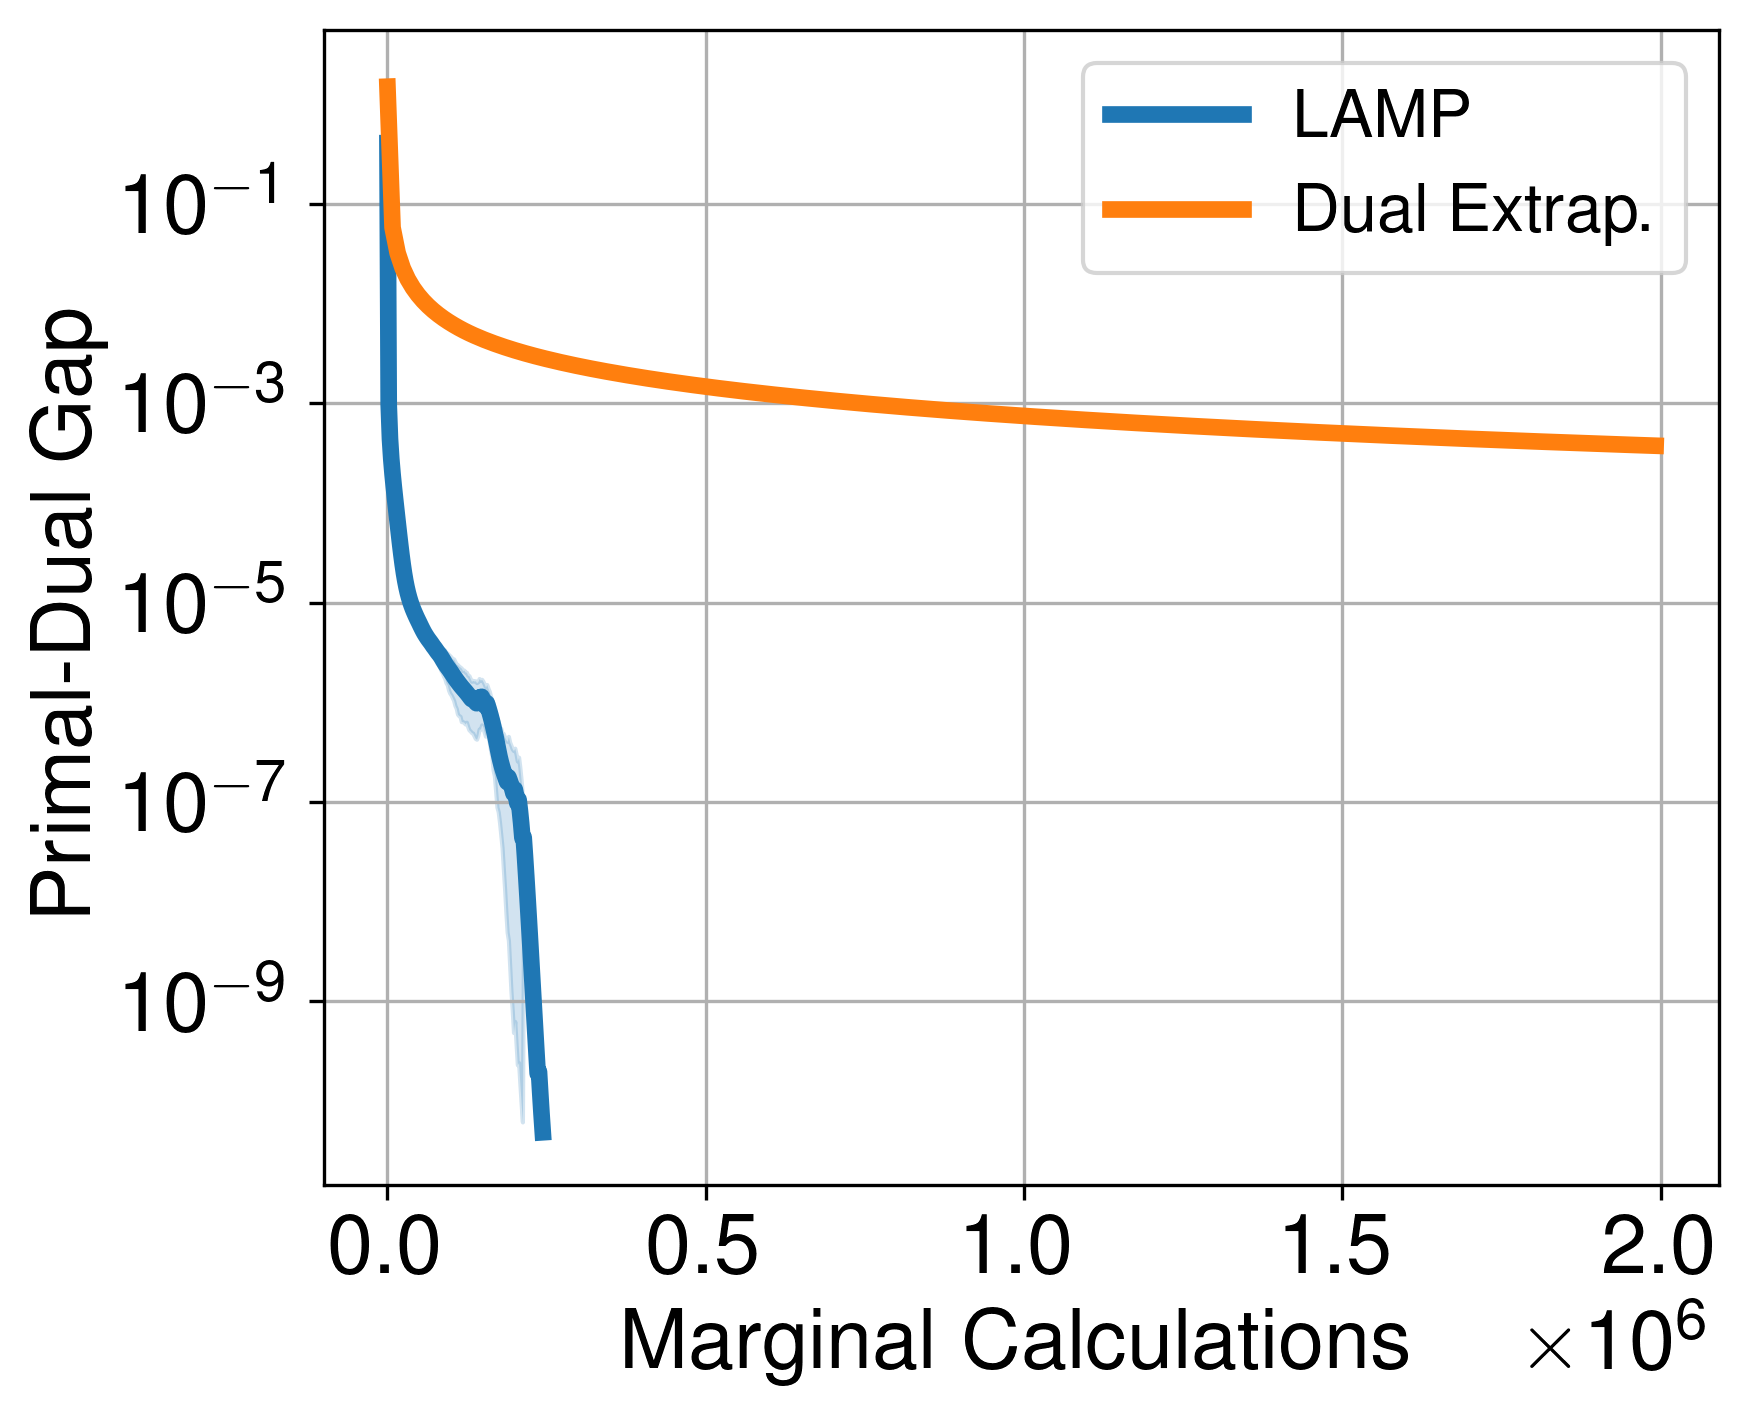

In [8]:
df = pd.read_csv("../data_archive/fig_5_dual_extrap_comp.csv")
df["Algorithm"].replace({"LAMP ($\\eta_p = 0$)": "LAMP"}, inplace=True)
fig, ax = plt.subplots(figsize=(6,5))
sns.lineplot(df.query("(iter-1) % 1000 == 0"),ax=ax, x='inner_iter', y='pdgap', hue='Algorithm', hue_order=["LAMP", "Dual Extrap."], linewidth=4)
ax.set_yscale('log')
ax.set_ylabel("Primal-Dual Gap")
ax.set_xlabel("Marginal Calculations")
ax.legend(fontsize=16)
ax.grid()
fig.savefig("../figures/dextrap_comparison.pdf", bbox_inches="tight")

In [9]:
from glob import glob
from tqdm import tqdm
import re
pattern = r"(\w+)_cells(\d+)_features(\d+)_([a-z1-9]+)_(\w+)_seed(\d+)_log"
optimal_df = pd.read_csv("../data/experiment_cellsim_broad/ground_truths_5000.csv")
skargs = dict(header=None, skipfooter=1, 
                      names=[
    "time(s)", "iter", "infeas", "ot_objective", "dual", "solver"
])
def load_df(path, **kwargs):
    dataset, ncells, nfeatures, metric, solver, seed = re.findall(pattern, path)[0]
    ncells, nfeatures, seed = map(int, [ncells, nfeatures, seed])
    
    if "sinkhorn" in path and "annealed" not in path:
        df = pd.read_csv(path, **skargs).iloc[1:]
    else:
        df = pd.read_csv(path, skipfooter=1)
    df['seed'] = seed; df['ncells'] = ncells; df["nfeatures"] = nfeatures; df['metric'] = metric
    df = df.merge(optimal_df, on=["metric", "seed", "nfeatures", "ncells"])
    df["compound_obj"] = np.abs(df["ot_objective"].astype(float) - df['cost']) + df["infeas"].astype(float) * df["Cinf"]
    df["time(s)"] = df["time(s)"].astype(float)
    return df
flist = glob("../data/experiment_cellsim_broad/*seed*_log.csv")
dflist = []
for f in tqdm(flist):
    df = load_df(f)
    dflist.append(df)
df = pd.concat(dflist).reset_index(drop=True)
arr = np.exp(pd.cut(np.log(df['time(s)']), bins=200 , precision=2,retbins=True)[0].apply(lambda x: x.mid).to_numpy())
# np.exp(arr[0].iloc[0].mid)
df['bintime'] = arr
df['Algorithm'] = df['solver'].replace({"lamp_kernel": "LAMP", 
                                        "annealed_sinkhorn_cellsim": "Anneal-SK",
                                        "sinkhorn_cellsim":  "SK"})
df["Metric"] = df['metric'].replace({
    "l1": "$\\ell_1$", 
    "l2": "$\\ell_2^2$",
    "correlation": "Pearson Correlation", 
    "cosine": "Cosine"
})
df.to_csv("../data_archive/fig_3_cellsim.csv", index=False)

  0%|          | 0/301 [00:00<?, ?it/s]/tmp/ipykernel_161988/1467859348.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(path, **skargs).iloc[1:]
/tmp/ipykernel_161988/1467859348.py:15: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(path, **skargs).iloc[1:]
/tmp/ipykernel_161988/1467859348.py:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(path, skipfooter=1)
/tmp/ipykernel_161988/1467859348.py:17: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(path, skipf

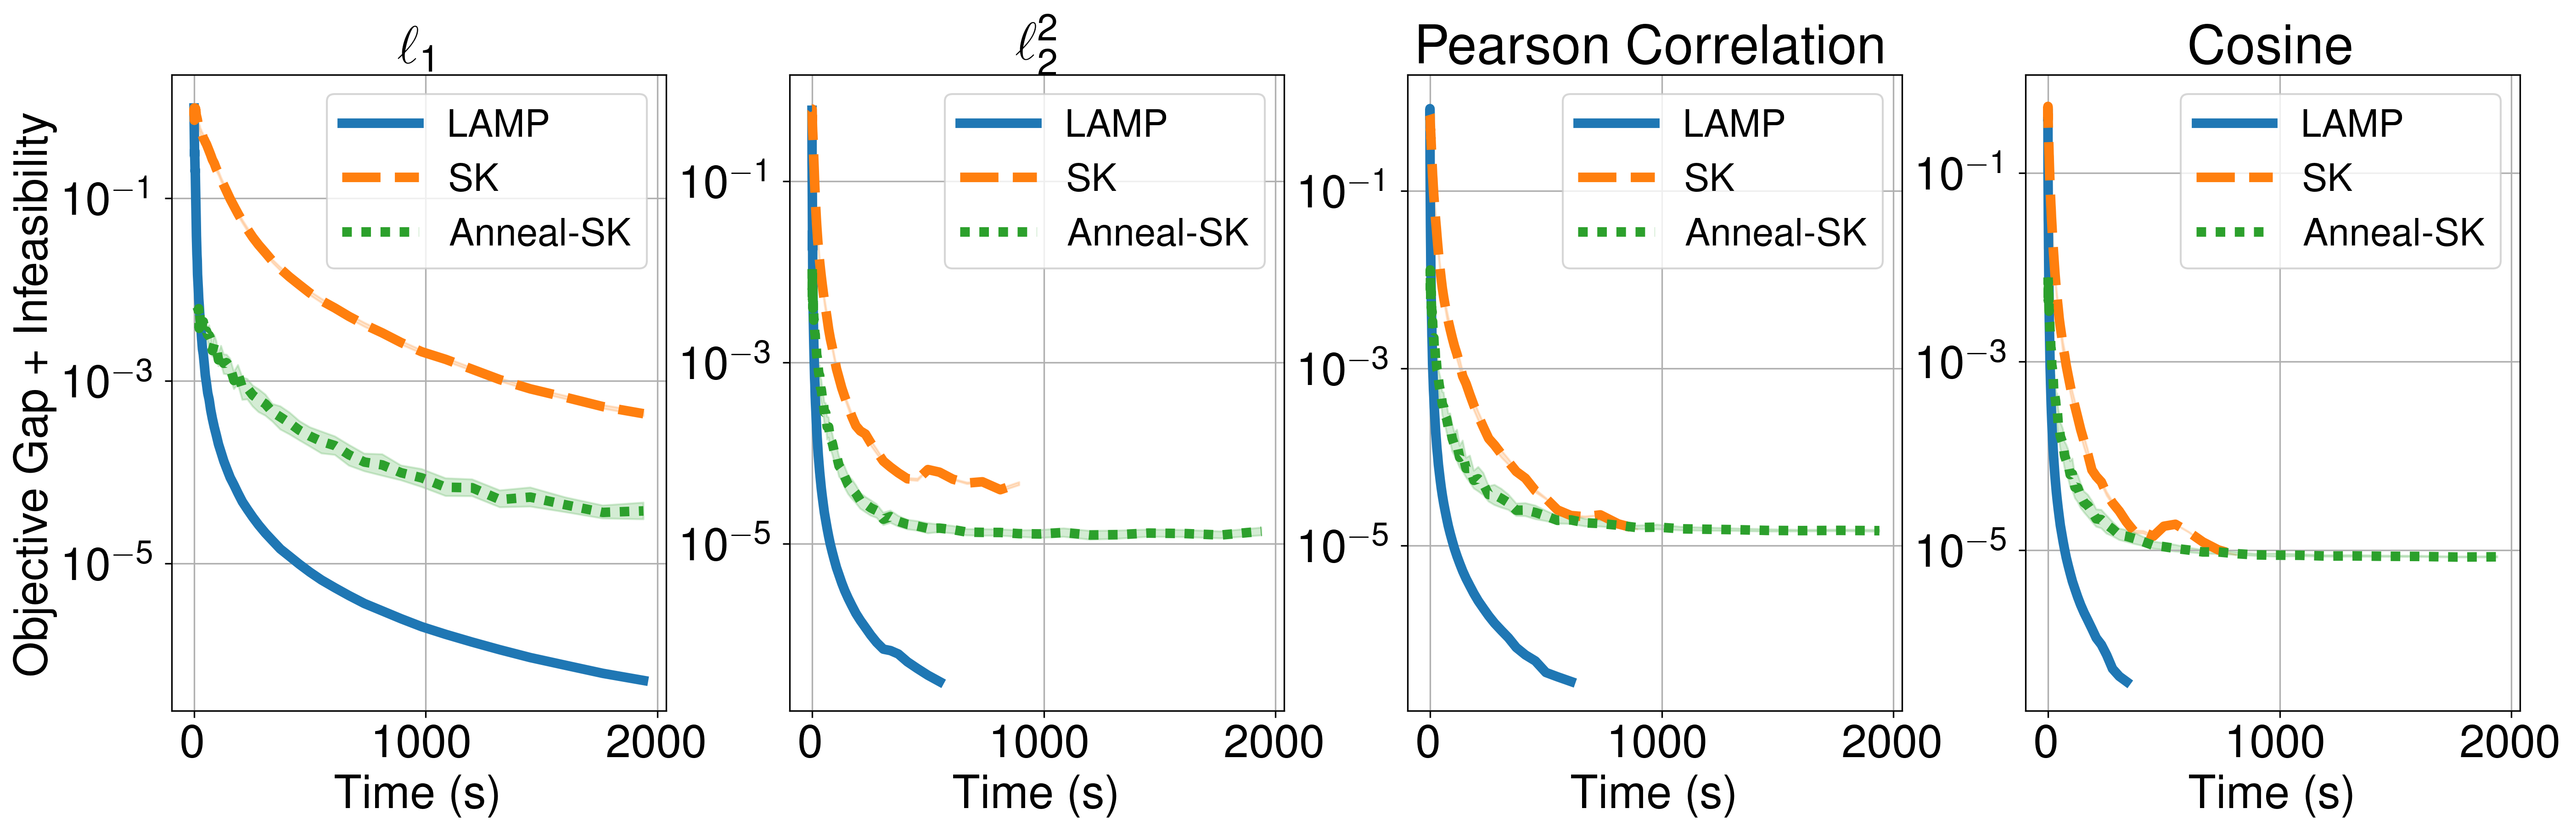

In [7]:
import matplotlib as mpl
fig, axs = plt.subplot_mosaic([["$\\ell_1$", "$\\ell_2^2$","Pearson Correlation", "Cosine"]], figsize=(22,6), gridspec_kw={"wspace": 0.25})
hue_order = ["LAMP", "SK", "Anneal-SK"]
first = True
mpl.rcParams['font.size']= 24
mpl.rcParams["figure.dpi"] = 300
# plt.rc('pdf',fonttype = 1)
# mpl.rcParams['text.usetex'] = True #Let TeX do the typsetting
# mpl.rcParams['text.latex.preamble'] = '\\usepackage{sansmath}\n\\sansmath' #Force sans-serif math mode (for axes labels)
# mpl.rcParams['font.family'] = 'sans-serif' # ... for regular text
# 
# mpl.rcParams['font.sans-serif'] = 'Helvetica' # Choose a nice font here
for metric in df['Metric'].unique():
    sns.lineplot(df.query(f"nfeatures==5000 and Metric == \"{metric}\" and `time(s)` < 2000"),
                 x='bintime', y='compound_obj', hue='Algorithm',style='Algorithm', ax=axs[metric], hue_order=hue_order, style_order=hue_order, linewidth=5)
    axs[metric].set_yscale("log")
    # axs[metric].set_xscale("log")
    axs[metric].set_title(f"{metric}", fontsize=28)
    if metric == "$\\ell_1$":
        axs[metric].set_ylabel("Objective Gap + Infeasibility")
    else:
        axs[metric].set_ylabel("")
    axs[metric].set_xlabel("Time (s)")
    axs[metric].grid()
    axs[metric].legend(fontsize=20)
    first = False
fig.savefig("../figures/UPDATED_REBUTTAL_cell_similarity_n5000.pdf", bbox_inches='tight')

In [4]:
from scipy.stats import gmean
target = 1e-4
lim_df = df.query(f"compound_obj < {target} and nfeatures != 10000").sort_values(by='time(s)').drop_duplicates(["Algorithm", "seed", "metric", "nfeatures"])
lim_df['iter'] = lim_df['iter'].astype(int)
lim_df.loc[lim_df["Algorithm"] == "LAMP", "iter"] *= 4
lim_df.loc[lim_df["Algorithm"] != "LAMP", "iter"] *= 2

aggdf = lim_df.query("nfeatures==5000").groupby(["Metric", "Algorithm", ]).agg({"time(s)": 'mean', "iter": "mean"}).round(2)
def multiindex_to_markdown(df):
    out = df.reset_index()  # puts each index level in its own column

    # blank repeated labels in index columns for a grouped look
    n_idx = df.index.nlevels
    for i in range(n_idx):
        mask = out.iloc[:, :i+1].eq(out.iloc[:, :i+1].shift()).all(axis=1)
        out.loc[mask, out.columns[i]] = ""

    return out.to_markdown(index=False)
piv_df = aggdf.pivot_table(index="Algorithm", columns="Metric", values=['time(s)', "iter"])
print(multiindex_to_markdown(aggdf))

# aggdf

| Metric      | Algorithm   |   time(s) |   iter |
|:------------|:------------|----------:|-------:|
| $\ell_1$    | Anneal-SK   |    887.82 |  28520 |
|             | LAMP        |    145.51 |   4684 |
|             | SK          |   2128.38 |  68222 |
| $\ell_2$    | Anneal-SK   |    102.51 |  23056 |
|             | LAMP        |     26.34 |   5836 |
|             | SK          |    264.19 |  57786 |
| Correlation | Anneal-SK   |    134.87 |  24152 |
|             | LAMP        |     33.13 |   5868 |
|             | SK          |    250.63 |  43818 |
| Cosine      | Anneal-SK   |     77.79 |  16056 |
|             | LAMP        |     24.17 |   4980 |
|             | SK          |    174.36 |  35078 |


In [98]:
from glob import glob
import re
patt = re.compile(r"features(\d+)_([a-z\d]+)")
flist = glob("../data/experiment_summability/*.csv")
dflist = []
for fname in flist:
    n, metric = patt.findall(fname)[0]
    df = pd.read_csv(fname)
    df["filename"] = fname
    # df['d'] = n
    df['n'] = int(n)
    df['metric'] = metric
    # df['p'] = p
    dflist.append(df)
df = pd.concat(dflist)
df.to_csv("../data_archive/cellsim_summability_updated.csv")
patt = re.compile(r"dotmark_p([\d\.]+|Inf)_([a-z]+)_size(\d+)")
flist = glob("../data/experiment_dotmark_summability/*.csv")
dflist = []
for fname in flist:
    p, classname, size = patt.findall(fname)[0]
    df = pd.read_csv(fname)
    df["filename"] = fname
    df["classname"] = classname
    # df['d'] = n
    df['n'] = int(size)**2
    df['p'] = p
    # df['p'] = p
    dflist.append(df)
df = pd.concat(dflist)
df.to_csv("../data_archive/dotmark_summability_updated.csv")

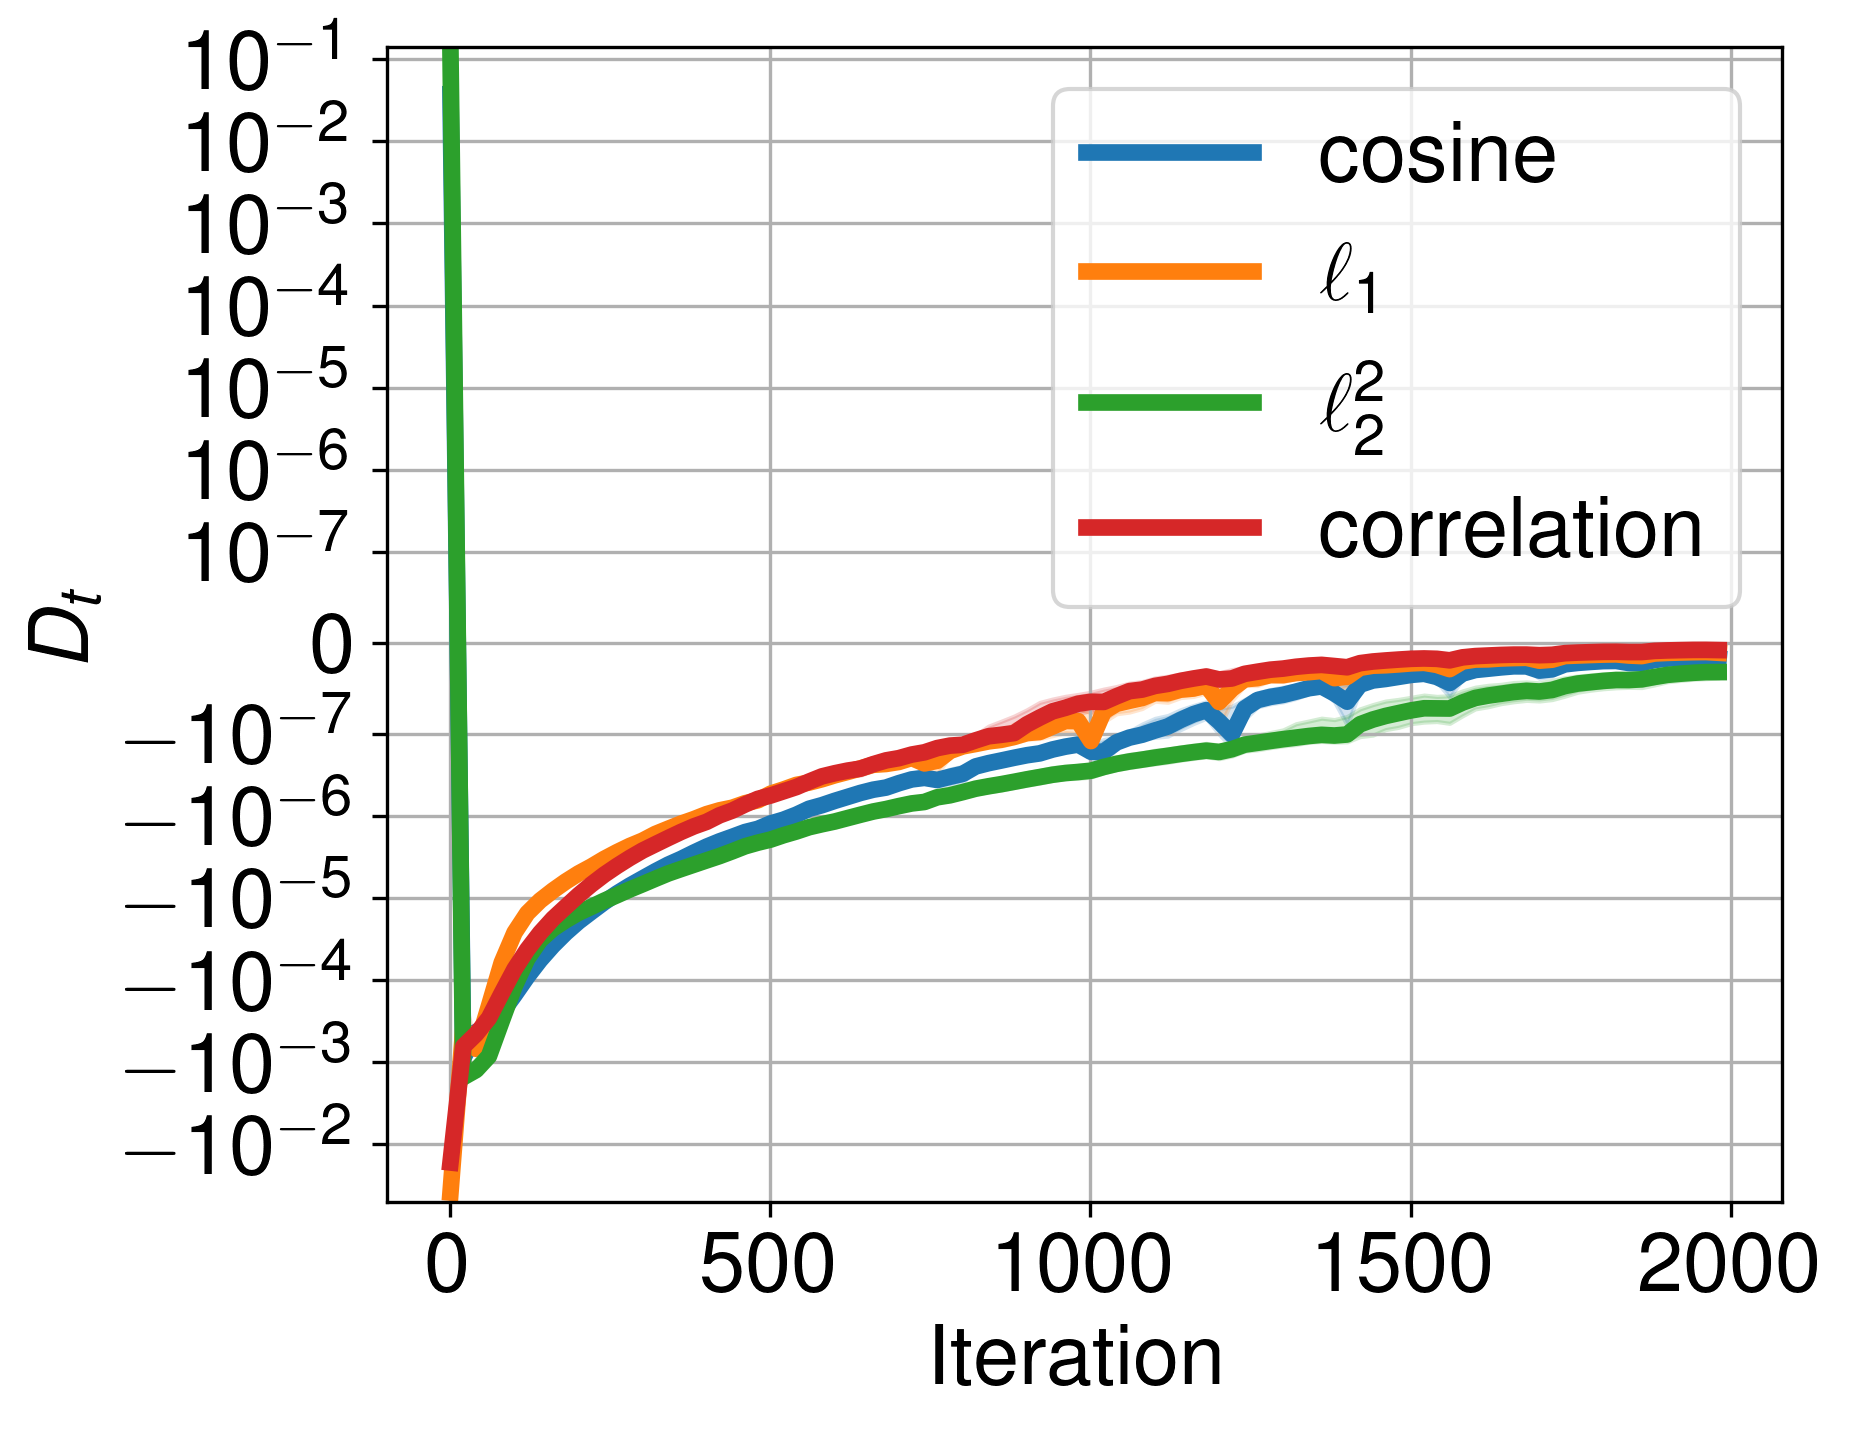

In [6]:
from glob import glob
import re
fig, ax = plt.subplots(figsize=(6,5))

df = pd.read_csv("../data_archive/cellsim_summability.csv")
df['$D_t$'] = df.groupby(['iteration', "metric", "filename"])['diff'].cumsum()
df["Metric"] = df['metric'].replace(
    {"l1": "$\ell_1$",
     "l2": "$\ell_2^2$"}
)

sns.lineplot(df.query("iteration < 2000"), ax=ax, x='iteration', y='$D_t$', hue="Metric", palette="tab10", linewidth=4)
ax.set_yscale('symlog', linthresh=0.0000001)
# ax.set_xscale('log')
ax.grid()
ax.set_xlabel("Iteration")
ax.legend(title=None, fontsize=20)
fig.savefig("../figures/cellsim_summability.pdf", bbox_inches='tight')

In [62]:
plotdf = df.melt(id_vars=['iteration', "metric", "filename"], value_vars=["Max", "Sum"], value_name="Measure")
plotdf

,iteration,metric,filename,variable,Measure
0,1,cosine,../data/experiment_summability/cell_summabilit...,Max,9.760299e-02
1,21,cosine,../data/experiment_summability/cell_summabilit...,Max,-5.917864e-04
2,41,cosine,../data/experiment_summability/cell_summabilit...,Max,-2.753240e-04
3,61,cosine,../data/experiment_summability/cell_summabilit...,Max,-1.617465e-04
4,81,cosine,../data/experiment_summability/cell_summabilit...,Max,-1.095908e-04
...,...,...,...,...,...
159995,9901,l2,../data/experiment_summability/cell_summabilit...,Sum,-1.462178e-10
159996,9921,l2,../data/experiment_summability/cell_summabilit...,Sum,-1.453785e-10
159997,9941,l2,../data/experiment_summability/cell_summabilit...,Sum,-1.445457e-10
159998,9961,l2,../data/experiment_summability/cell_summabilit...,Sum,-1.437191e-10


In [48]:
df.query("diff==diff").groupby(['filename'])['diff'].max()

filename
../data/experiment_summability/cell_summability_liu_scatac_preprocessed_cells50_features1024_correlation_cella11_cellb2_log.csv    -3.938871e-11
../data/experiment_summability/cell_summability_liu_scatac_preprocessed_cells50_features1024_correlation_cella18_cellb34_log.csv    1.075876e-02
../data/experiment_summability/cell_summability_liu_scatac_preprocessed_cells50_features1024_correlation_cella19_cellb33_log.csv   -4.087454e-11
../data/experiment_summability/cell_summability_liu_scatac_preprocessed_cells50_features1024_correlation_cella28_cellb26_log.csv   -3.236095e-11
../data/experiment_summability/cell_summability_liu_scatac_preprocessed_cells50_features1024_correlation_cella39_cellb50_log.csv   -2.179296e-11
                                                                                                                                        ...     
../data/experiment_summability/cell_summability_liu_scatac_preprocessed_cells50_features576_l2_cella32_cellb22_log.csv   

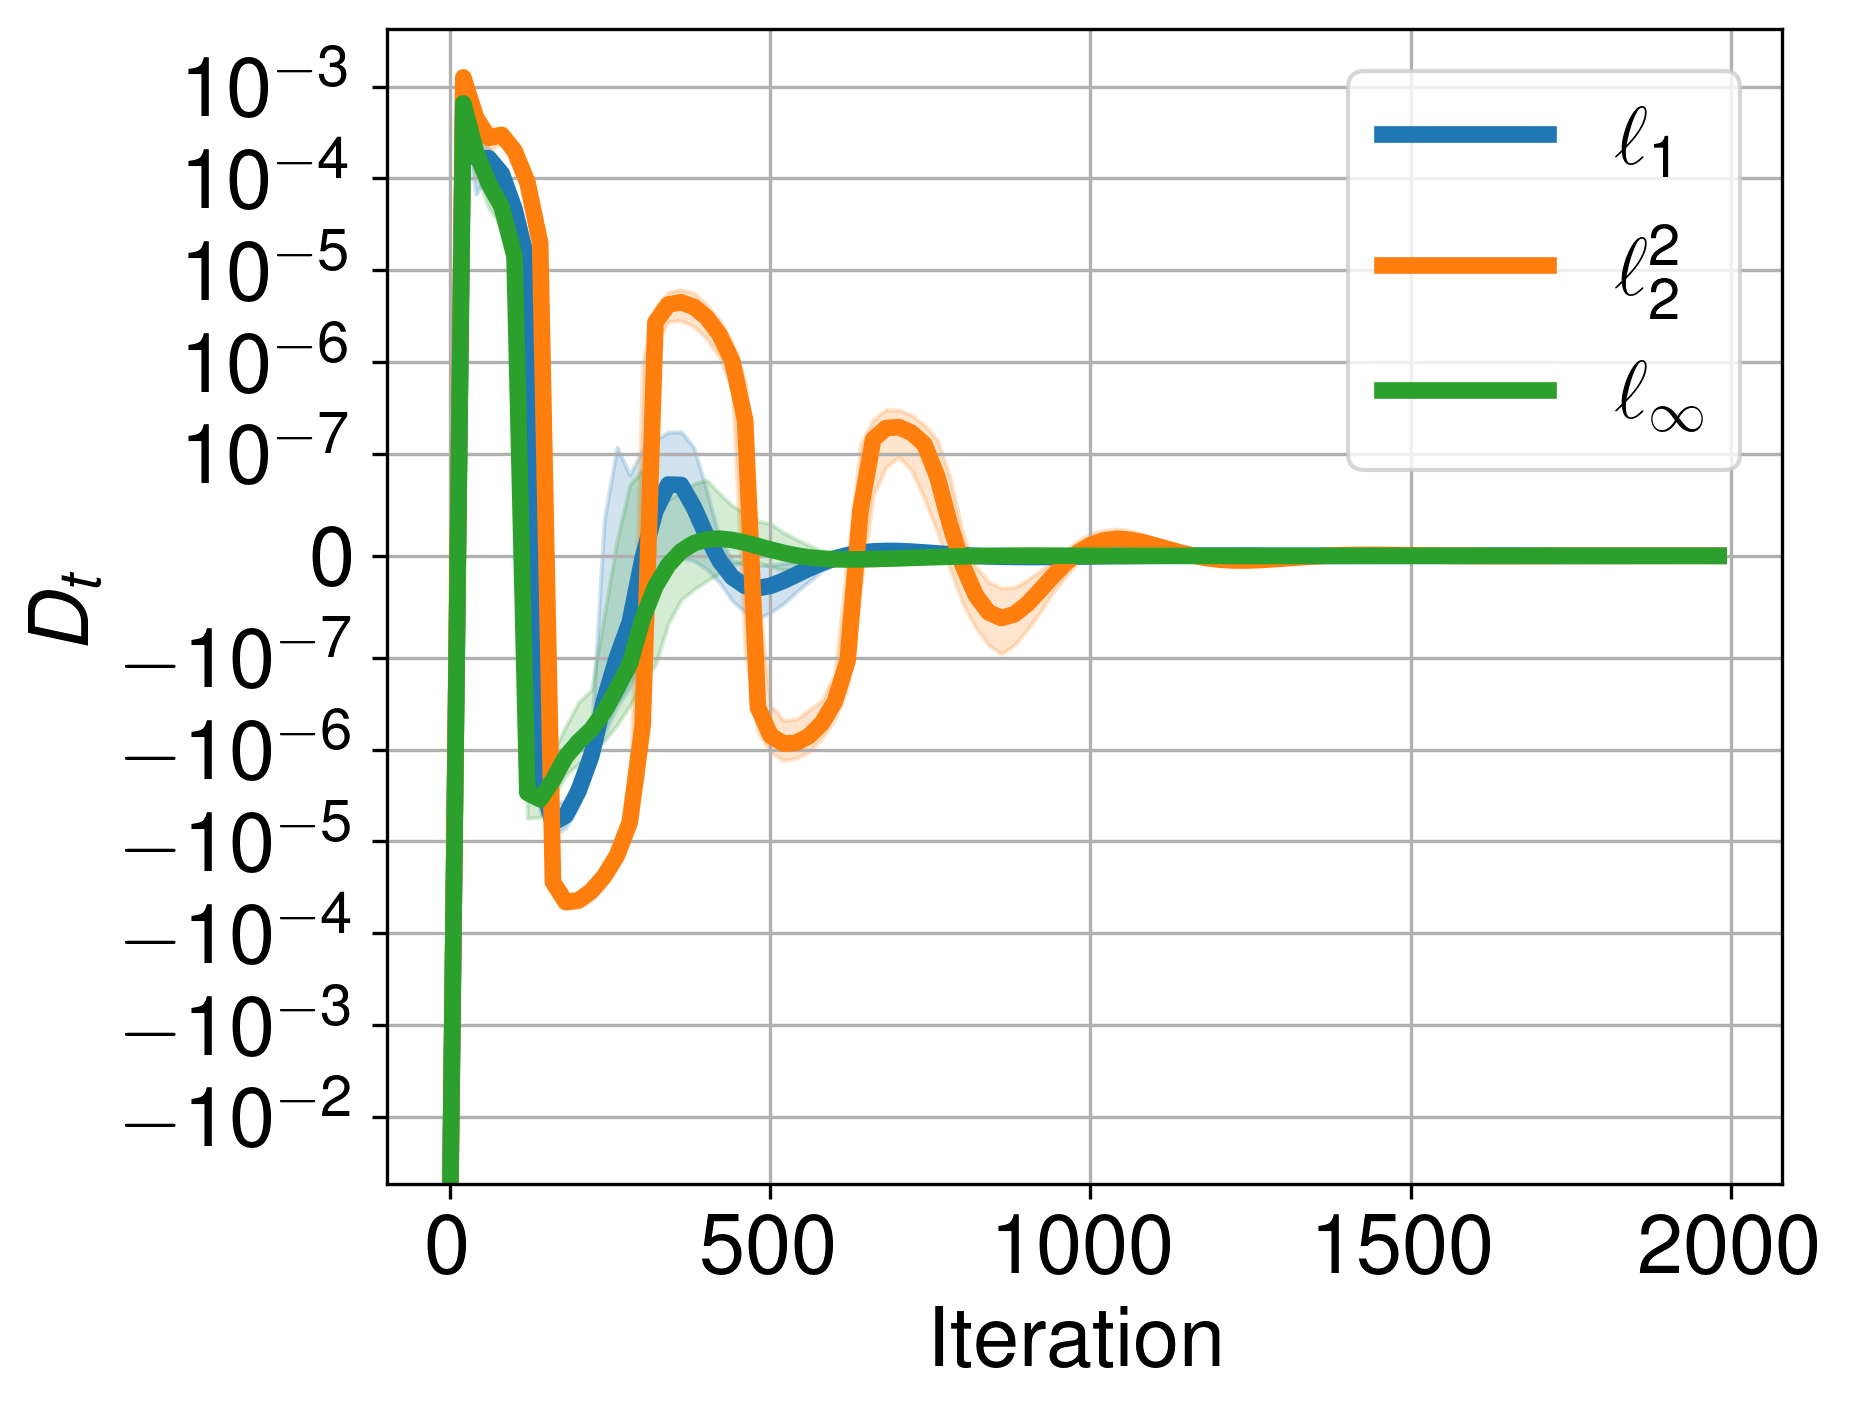

In [97]:
fig, ax = plt.subplots(figsize=(6,5))

df = pd.read_csv("../data_archive/dotmark_summability.csv")
df['Max'] = df.groupby(['iteration', "p"])['diff'].transform("max")
df['$D_t$'] = df.groupby(['iteration', "p", "filename"])['diff'].cumsum()
df["$p$"] = df['p'].replace(
    {1.0: "$\ell_1$",
     2.0: "$\ell_2^2$",
     np.inf: "$\ell_\infty$",}
)

sns.lineplot(df.query("iteration < 2000"), ax=ax, x='iteration', y='$D_t$', hue="$p$", palette="tab10", linewidth=4)
ax.set_yscale('symlog', linthresh=0.0000001)
# ax.set_xscale('log')
ax.grid()
ax.set_xlabel("Iteration")
ax.legend(title=None, fontsize=20)
fig.savefig("../figures/dotmark_summability.pdf", bbox_inches='tight')

In [ ]:
df['p']

0        1.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
89995    2.0
89996    2.0
89997    2.0
89998    2.0
89999    2.0
Name: p, Length: 90000, dtype: float64